### Source setup and configuration

This notebook shows how to set up the numerical parameters to perform time-to-frequency domain transformations.

In [1]:
import numpy as np
from src.utilities import ricker_wavelet, low_freq_taper
from src.kernels import green2d
from src.plot.plot_tools import plot_signal_time_freq

We first specify the total simulation time and the central frequency in Hz.

In [2]:
total_time = 1.0  # simulation time [sec]
f0 = 10.0  # Ricker central frequency (Hz)

We fix the maximum and minimum frequencies covered by the source. Then, we choose the time-resolution $dt$, given $f_{max}$, based on the Nyquist criterion.  

This allows us to define the time-axis and the number of points for the frequency domain FFT.

In [3]:
f_max = 8.0 * f0    # Ricker max-frequency for cutoff
# set approx. Nyquist frequency for f_max
dt = 1/(2.*f_max) # minimum dt
print("time step dt =", dt, "sec")
# time array
nt = int(total_time / dt) + 1 
time = np.arange(nt) * dt
# zero-pad to the next power of 2 for fft
nfft = 2**int(np.ceil(np.log2(nt)))
# to prevent wrap-around we can again multiply nfft by 2
nfft *= 2 # also improves frequency interpolation
print("number of time points nt =", nt)
print("number of fft points (power of two), nfft =", nfft)

time step dt = 0.00625 sec
number of time points nt = 161
number of fft points (power of two), nfft = 512


We can now generate our seismic source function in the time-domain, and converted into the frequency domain using fft. 

We suppose the source is a standard Ricker wavelet. 

Here, we are using the $-i \omega t$ convention (physics convention), but note that Python uses the $+i \omega t$ convention by default. 

The ricker source is delayed by 0.15 sec to ensure causality
frequency spacing df = 0.3125 Hz


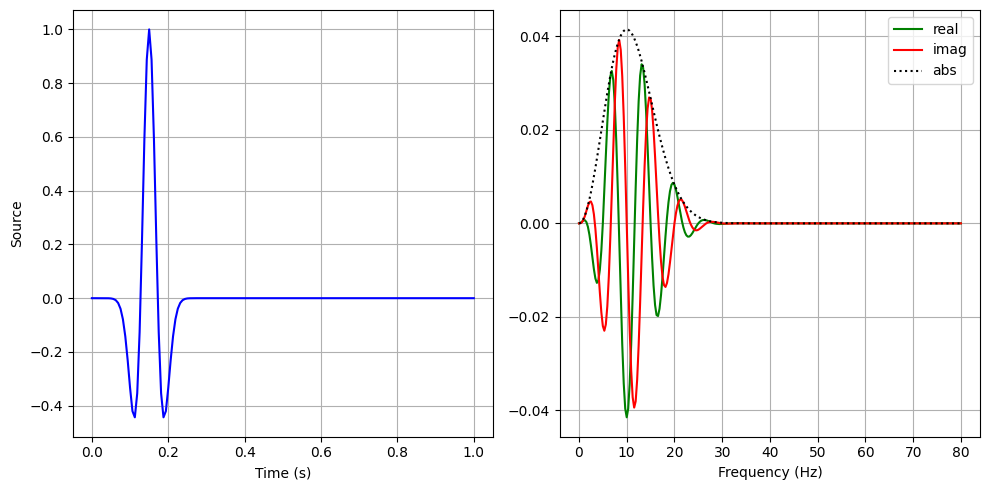

In [4]:
delay = 0.15
s_t = ricker_wavelet(time, f0, delay)
print("The ricker source is delayed by", delay, "sec to ensure causality")
# take the conjugate to stick to the -i*w*t convetion !
s_w = np.conj(np.fft.rfft(s_t, n=nfft)) # fft for a real input
s_w *= dt # for normalization
freqs = np.fft.rfftfreq(nfft, dt)
print("frequency spacing df =", freqs[1] - freqs[0], 'Hz')
plot_signal_time_freq(time, s_t, freqs, s_w)

We now multiply the source with the frequency domain 2D Green kernel, and go back in time by inverse FFT.

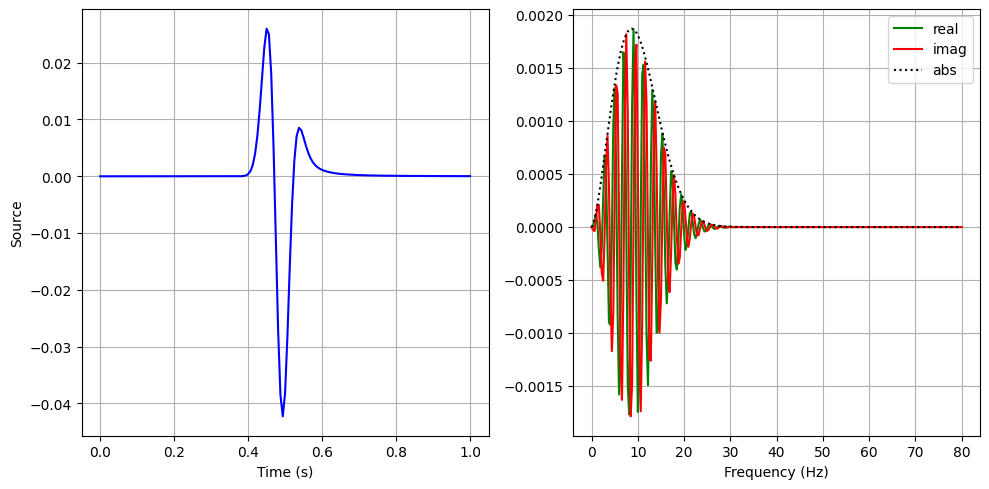

In [5]:
omega = 2.*np.pi*freqs
# multiply the source by a signal and do inverse FFT
G = green2d(omega, c=1800., distances=600.)
# convolution = multiplication in the frequency domain
signal_w = G.flatten()*s_w
# filter low-frequencies below f_min
f_min = 0.1 # [Hz]
signal_w *= low_freq_taper(omega, omega_min=2*np.pi*f_min)
# inverse FFT
signal_time = np.fft.irfft(np.conj(signal_w), n=nfft) / dt
# truncate to the number of time points
signal_time = signal_time[:nt]
plot_signal_time_freq(time, signal_time, freqs, signal_w)

We obtain the time-domain response at a receiver located at 600m from the source in a homogeneous medium. 
 
We can now use this workflow to convolve the source with more advanced frequency-domain signals.